In [5]:
import pandas as pd
df = pd.read_csv('studentdata.csv' , sep=';')
df

,Unnamed: 0,Deutsche,Deutsche.1,Deutsche.2,Deutsche.3,Deutsche.4,Deutsche.5,Deutsche.6,Deutsche.7,Ausländer,Ausländer.1,Ausländer.2,Ausländer.3,Ausländer.4,Ausländer.5,Ausländer.6,Ausländer.7
0,NaN,männlich,männlich,männlich,männlich,weiblich,weiblich,weiblich,weiblich,männlich,männlich,männlich,männlich,weiblich,weiblich,weiblich,weiblich
1,NaN,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung
2,1999.0,118454,e,1641,e,91484,e,921,e,6851,e,125,e,4907,e,67,e
3,2000.0,111000,e,1541,e,90682,e,951,e,7396,e,153,e,5395,e,74,e
4,2001.0,104670,e,1552,e,89650,e,944,e,7792,e,154,e,6011,e,102,e
5,2002.0,102147,e,1414,e,91350,e,924,e,8404,e,182,e,6705,e,113,e
6,2003.0,103379,e,1392,e,97803,e,751,e,9198,e,146,e,7766,e,103,e
7,2004.0,107806,e,1503,e,103547,e,976,e,10581,e,200,e,9006,e,121,e
8,2005.0,114996,e,1309,e,113754,e,984,e,12515,e,214,e,11217,e,163,e
9,2006.0,118359,e,1532,e,121374,e,900,e,13276,e,287,e,12695,e,181,e


In [60]:
df = pd.read_csv('studentdata.csv')

In [61]:
import sqlite3

# Establish a connection to an SQLite database
conn = sqlite3.connect("my_database.db")

# Read data from a table
df.to_sql("my_table", conn, if_exists="replace", index=False)
df = pd.read_sql("SELECT * FROM my_table", conn)

In [62]:
df.to_csv("studentdata_out.csv", index=False)

In [63]:
df.to_json("studentdata_out.json")

In [64]:
df.to_csv('studentdata_out.txt', header=df.columns, index=None, sep=';')

In [65]:
df.to_csv("studentdata_out.csv", index=False)

In [66]:
df.head()

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
0,;männlich;männlich;männlich;männlich;weiblich;...
1,;Bestandene Prüfung;Bestandene Prüfung;Nichtbe...
2,1999;118454;e;1641;e;91484;e;921;e;6851;e;125;...
3,2000;111000;e;1541;e;90682;e;951;e;7396;e;153;...
4,2001;104670;e;1552;e;89650;e;944;e;7792;e;154;...


In [67]:
df.tail(n = 10)

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
18,2015;216616;e;12233;e;218538;e;5194;e;23303;e;...
19,2016;217922;e;11749;e;224644;e;5169;e;24852;e;...
20,2017;220222;e;12120;e;228779;e;5645;e;26474;e;...
21,2018;216217;e;13672;e;227458;e;6504;e;27575;e;...
22,2019;216973;e;14525;e;235306;e;7264;e;30664;e;...
23,2020;200355;e;9127;e;218888;e;4838;e;29798;e;1...
24,2021;210903;e;4309;e;241594;e;2460;e;33257;e;1...
25,2022;204436;e;5257;e;233200;e;2806;e;35255;e;1...
26,2023;199625;e;10434;e;232158;e;5329;e;37056;e;...
27,2024;200459;e;11756;e;236075;e;6497;e;39551;e;...


In [68]:
df.describe()

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
count,28
unique,28
top,;männlich;männlich;männlich;männlich;weiblich;...
freq,1


In [69]:
df.describe(percentiles=[0.3, 0.5, 0.7])

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
count,28
unique,28
top,;männlich;männlich;männlich;männlich;weiblich;...
freq,1


In [70]:
df.describe(exclude=[int])

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
count,28
unique,28
top,;männlich;männlich;männlich;männlich;weiblich;...
freq,1


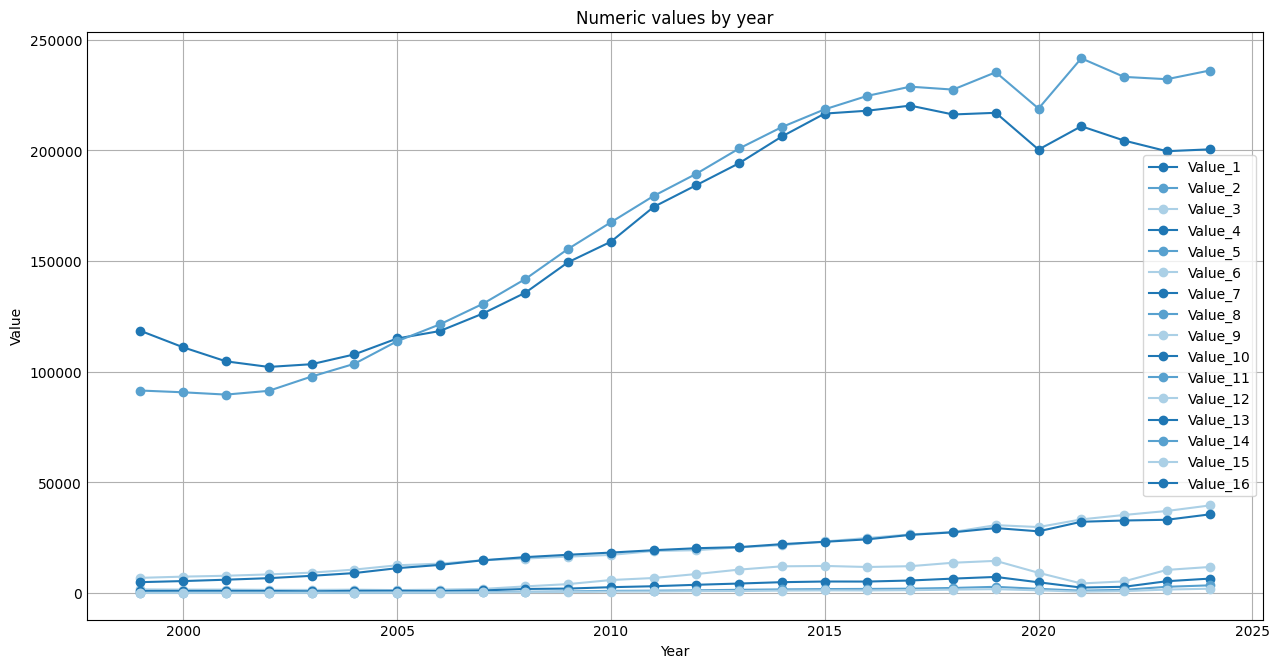

In [74]:
import matplotlib.pyplot as plt

plot_df = df.iloc[2:].copy()
plot_df = plot_df.rename(columns={'Unnamed: 0': 'Year'})
plot_df = plot_df.iloc[:, 0].str.split(';', expand=True)
plot_df.columns = ['Year'] + [f'Value_{i}' for i in range(1, plot_df.shape[1])]
plot_df['Year'] = pd.to_numeric(plot_df['Year'], errors='coerce')

for col in plot_df.columns.drop('Year'):
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

plot_df = plot_df.set_index('Year')
numeric_df = plot_df.select_dtypes(include='number')

numeric_df.plot(figsize=(12, 6), marker='o')
plt.title('Numeric values by year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(True)
plt.legend(loc='best')

<Axes: xlabel='1'>

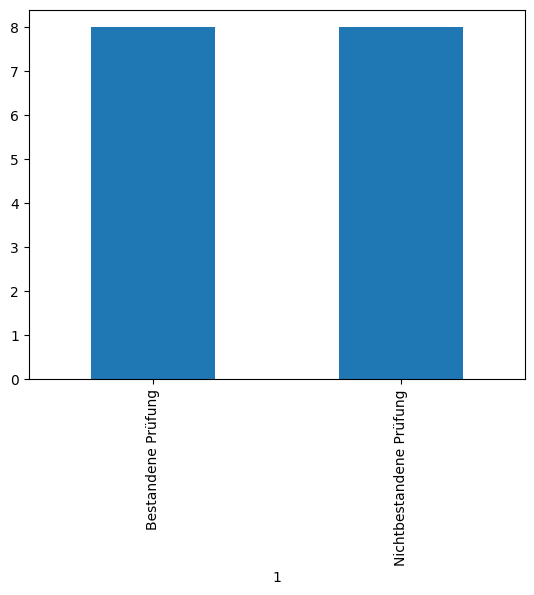

In [ ]:
df.iloc[1].value_counts().plot.bar()

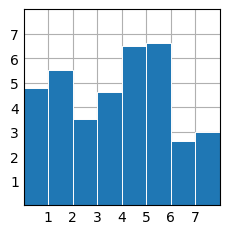

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data:
x = 0.5 + np.arange(8)
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
fig, ax = plt.subplots()

ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

In [ ]:
hist_counts, bin_edges = np.histogram(x, bins=8)
hist_df = pd.DataFrame({
    'bin_left': bin_edges[:-1],
    'bin_right': bin_edges[1:],
    'count': hist_counts
})
hist_df.to_csv("histogram_data.csv", index=False)


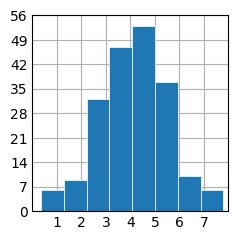

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data
np.random.seed(1)
x = 4 + np.random.normal(0, 1.5, 200)

# plot:
fig, ax = plt.subplots()

ax.hist(x, bins=8, linewidth=0.5, edgecolor="white")

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 56), yticks=np.linspace(0, 56, 9))

plt.show()

In [ ]:
import matplotlib.pyplot as plt

status_counts = (
	df.iloc[1]
	  .astype(str)
	  .str.split(';')
	  .explode()
	  .str.strip()
)

status_counts = (
	status_counts[status_counts != ""]
	  .replace({
		  "Bestandene Prüfung": "Bestanden",
		  "Nichtbestandene Prüfung": "Nicht bestanden",
		  "pass": "Bestanden",
		  "fail": "Nicht bestanden",
		  "Passed": "Bestanden",
		  "Failed": "Nicht bestanden",
	  })
	  .value_counts()
	  .reindex(["Bestanden", "Nicht bestanden"], fill_value=0)
)

plt.figure(figsize=(6, 4))
status_counts.plot(kind="bar")
plt.title("Bestanden vs Nicht bestanden")
plt.xlabel("Status")
plt.ylabel("Anzahl")
plt.tight_layout()
plt.show()

KeyError: 'Pass'

<Figure size 600x400 with 0 Axes>

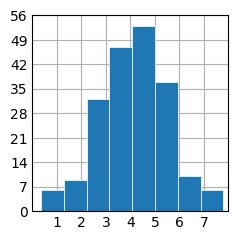

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data
np.random.seed(1)
x = 4 + np.random.normal(0, 1.5, 200)

# plot:
fig, ax = plt.subplots()

ax.hist(x, bins=8, linewidth=0.5, edgecolor="white")

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 56), yticks=np.linspace(0, 56, 9))

plt.show()

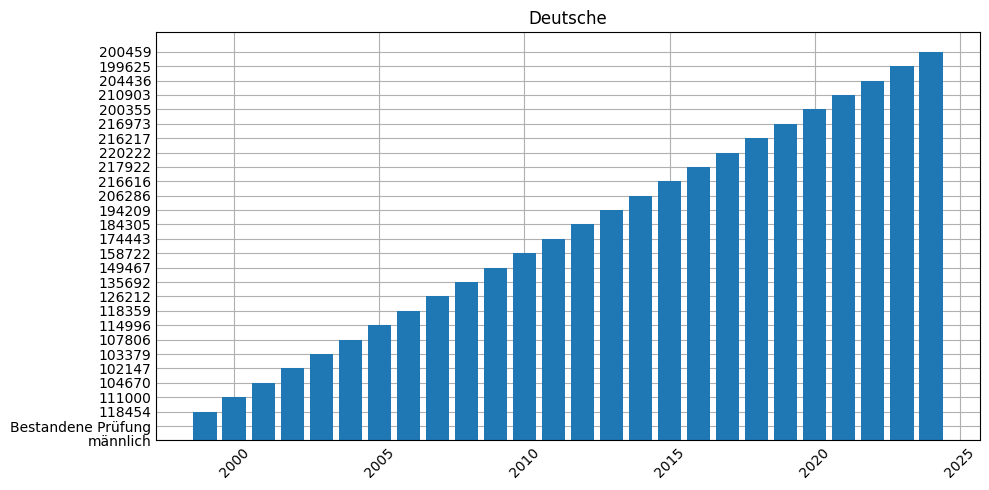

In [7]:
plt.figure(figsize=(10,5))
plt.bar(df["Unnamed: 0"], df["Deutsche"])

plt.title("Deutsche")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df.head()

,Unnamed: 0,Deutsche,Deutsche.1,Deutsche.2,Deutsche.3,Deutsche.4,Deutsche.5,Deutsche.6,Deutsche.7,Ausländer,Ausländer.1,Ausländer.2,Ausländer.3,Ausländer.4,Ausländer.5,Ausländer.6,Ausländer.7
0,NaN,männlich,männlich,männlich,männlich,weiblich,weiblich,weiblich,weiblich,männlich,männlich,männlich,männlich,weiblich,weiblich,weiblich,weiblich
1,NaN,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung
2,1999.0,118454,e,1641,e,91484,e,921,e,6851,e,125,e,4907,e,67,e
3,2000.0,111000,e,1541,e,90682,e,951,e,7396,e,153,e,5395,e,74,e
4,2001.0,104670,e,1552,e,89650,e,944,e,7792,e,154,e,6011,e,102,e


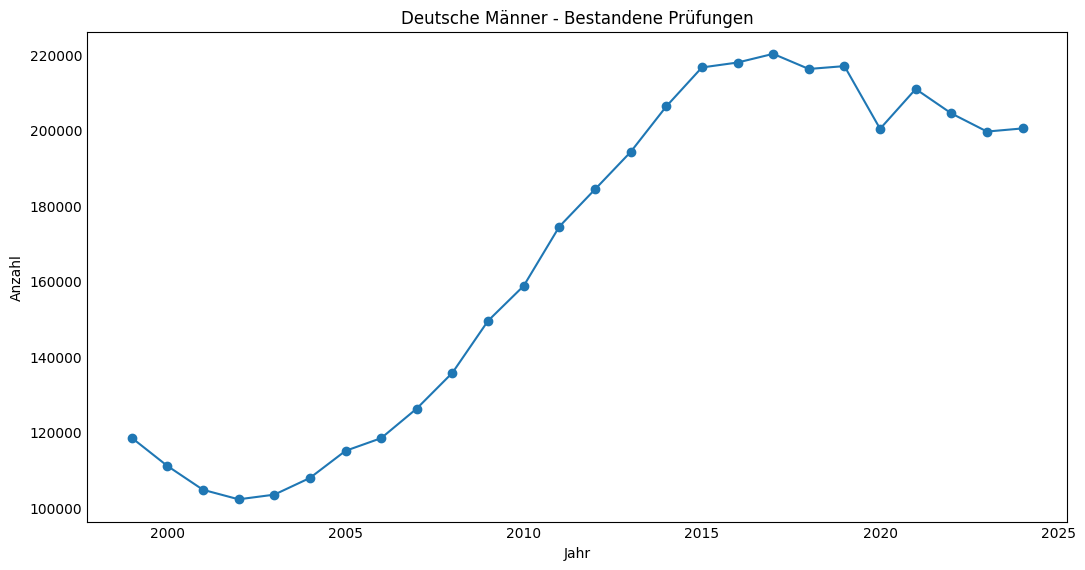

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df.iloc[2:, 0], df.iloc[2:, 1].astype(int), marker="o")
plt.title("Deutsche Männer - Bestandene Prüfungen")
plt.xlabel("Jahr")
plt.ylabel("Anzahl")
plt.grid()
plt.show()

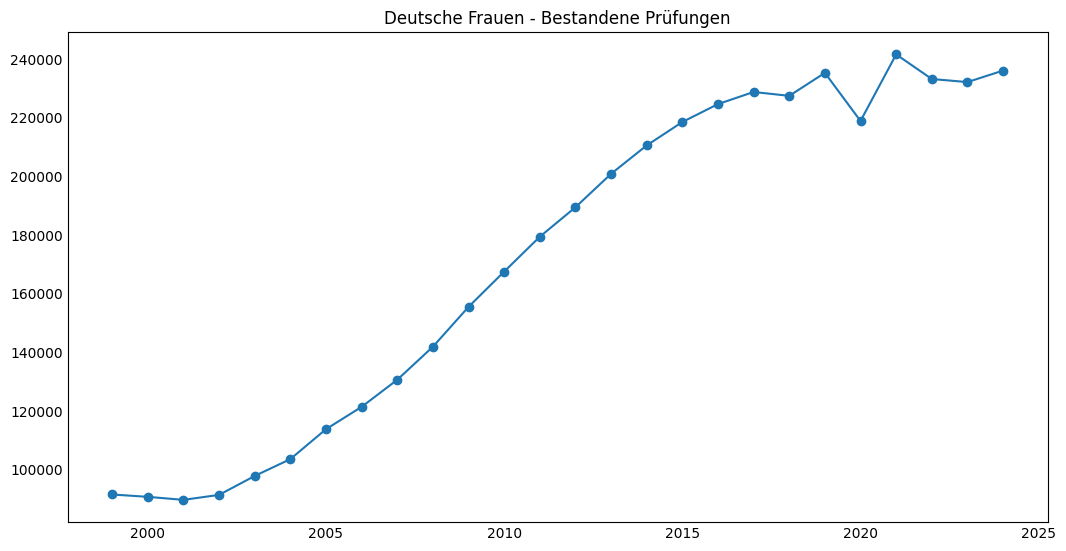

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[2:, 0], df.iloc[2:, 5].astype(int), marker="o")
plt.title("Deutsche Frauen - Bestandene Prüfungen")
plt.grid()
plt.show()

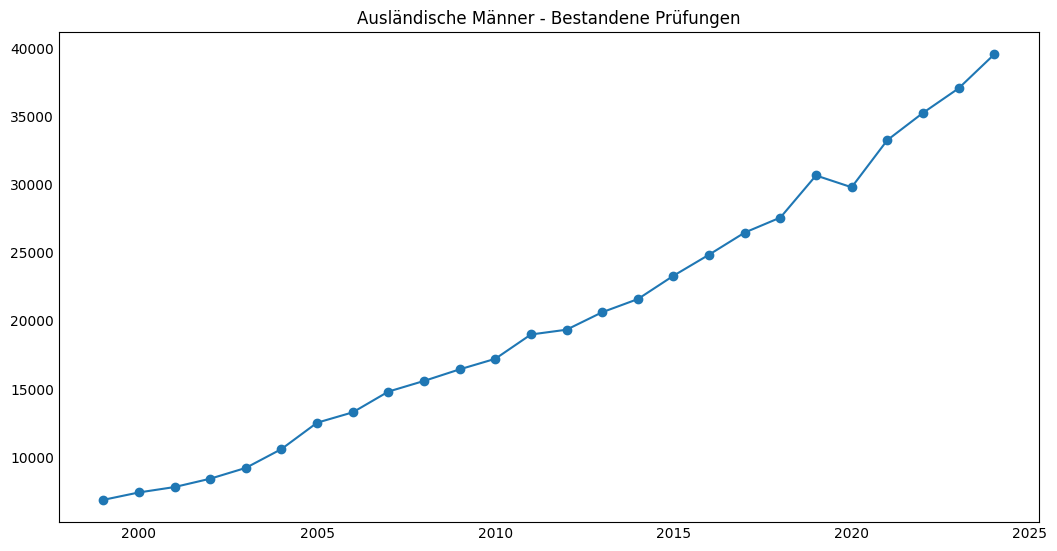

In [11]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[2:, 0], df.iloc[2:, 9].astype(int), marker="o")
plt.title("Ausländische Männer - Bestandene Prüfungen")
plt.grid()
plt.show()

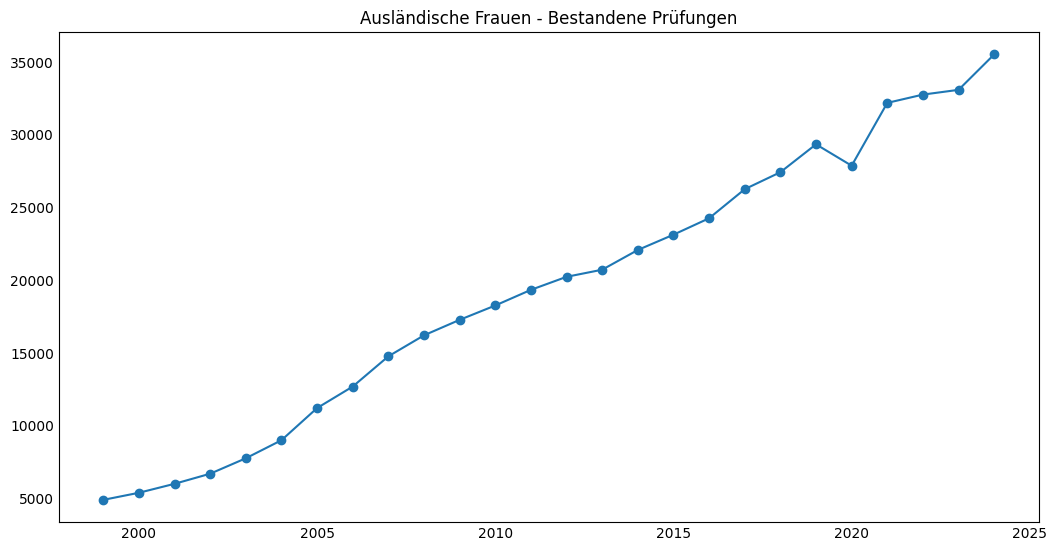

In [12]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[2:, 0], df.iloc[2:, 13].astype(int), marker="o")
plt.title("Ausländische Frauen - Bestandene Prüfungen")
plt.grid()
plt.show()

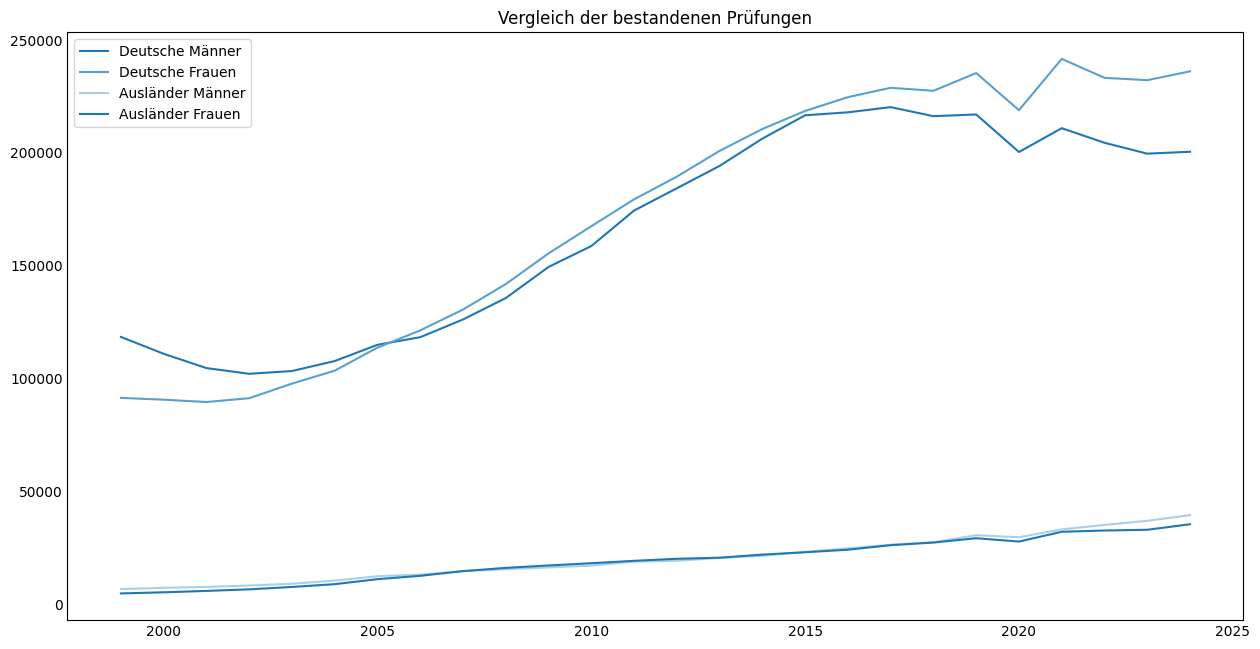

In [13]:
plt.figure(figsize=(12,6))

plt.plot(df.iloc[2:,0], df.iloc[2:,1].astype(int), label="Deutsche Männer")
plt.plot(df.iloc[2:,0], df.iloc[2:,5].astype(int), label="Deutsche Frauen")
plt.plot(df.iloc[2:,0], df.iloc[2:,9].astype(int), label="Ausländer Männer")
plt.plot(df.iloc[2:,0], df.iloc[2:,13].astype(int), label="Ausländer Frauen")

plt.legend()
plt.grid()
plt.title("Vergleich der bestandenen Prüfungen")
plt.show()